## Import the libaries needed for the ANN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
from keras.layers import LeakyReLU
from tensorflow.keras.metrics import RootMeanSquaredError
from keras.layers import Reshape
from keras.layers import LSTM

# Set random seed for reproducibility
np.random.seed(42)


In [2]:
# Map the different file names and paths
file_map = {
    "train_val_test": "training-val-test-data.npz",
    "hidden_test_pred": "hidden-test-prediction-submission-file.npz",
    "hidden_test_sim": "hidden-test-simulation-submission-file.npz",
}

########################################################
# Load the train_val_test first for training the model #
########################################################
file_name = file_map["train_val_test"]  
data = np.load(file_name)
print("Names of arrays for train_val_test data:", data.files)
print("Shape of u and th:", data['u'].shape, data['th'].shape)

# Split the data into u and th
u = data['u'].reshape(-1,1)
th = data['th'].reshape(-1,1)
print("Reshaped data of u and th:", u.shape, th.shape)

# Create a train, validation and test split for the data 
u_trainval, u_test, th_trainval, th_test = train_test_split(u, th, test_size=0.1, shuffle=False)
u_train, u_val, th_train, th_val = train_test_split(u_trainval, th_trainval, test_size=1/9, shuffle=False)

# Print shapes to confirm
print("Training set shapes:", u_train.shape, th_train.shape)
print("Validation set shapes:", u_val.shape, th_val.shape)
print("Test set shapes:", u_test.shape, th_test.shape)
print("\n")

####################################################
# Load the hidden_test_pred for making predictions #
####################################################
file_name = file_map["hidden_test_pred"]  
pred_data = np.load(file_name)
print("Names of arrays for hidden_test_pred data:", pred_data.files)
print("Shape of upast, thpast and thnow:", pred_data['upast'].shape, pred_data['thpast'].shape, pred_data['thnow'].shape)

# Split the data into u and th
pred_upast = pred_data['upast']
pred_thpast = pred_data['thpast']
pred_thnow = pred_data['thnow'].reshape(-1,1)

print("Reshaped data of pred_upast, pred_thpast and pred_thnow:", pred_upast.shape, pred_thpast.shape, pred_thnow.shape)
print("\n")

###########################################
# Load the hidden_test_sim for simulation # ---------------------> only first 50 rows have th data, need to simulate the 4950 th values using u 
###########################################
file_name = file_map["hidden_test_sim"]  
sim_data = np.load(file_name)
print("Names of arrays for hidden_test_sim:", sim_data.files)
print("Shape of sim_u and sim_th:", sim_data['u'].shape, sim_data['th'].shape)

# Split the data into u and th
sim_u = sim_data['u'].reshape(-1,1)
sim_th = sim_data['th'].reshape(-1,1)
print("Reshaped data of u and th:", u.shape, th.shape)



Names of arrays for train_val_test data: ['u', 'th']
Shape of u and th: (35000,) (35000,)
Reshaped data of u and th: (35000, 1) (35000, 1)
Training set shapes: (28000, 1) (28000, 1)
Validation set shapes: (3500, 1) (3500, 1)
Test set shapes: (3500, 1) (3500, 1)


Names of arrays for hidden_test_pred data: ['upast', 'thpast', 'thnow']
Shape of upast, thpast and thnow: (645, 15) (645, 15) (645,)
Reshaped data of pred_upast, pred_thpast and pred_thnow: (645, 15) (645, 15) (645, 1)


Names of arrays for hidden_test_sim: ['u', 'th']
Shape of sim_u and sim_th: (5000,) (5000,)
Reshaped data of u and th: (35000, 1) (35000, 1)


# Train the model with the training data 


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:  6.3min
[Parallel(n_jobs=-1)]: Done  58 tasks      | elapsed:  8.9min
[Parallel(n_jobs=-1)]: Done  73 tasks      | elapsed: 11.5min
[Parallel(n_jobs=-1)]: Done  88 tasks      | elapsed: 14.0min
[Parallel(n_jobs=-1)]: Done 105 tasks      | elapsed: 17.3min
[Parallel(n_jobs=-1)]: Done 122 tasks      | elapsed: 21.5min
[Parallel(n_jobs=-1)]: Done 141 tasks      | elapsed: 25.5min
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed: 29.9min
[Parallel(n_jobs=-1)]: Done 181 tasks      | elapsed: 36.3min
[Parallel(n_jobs=-1)]: Done 209 out of 225 | elapsed: 44.9min remaining:  3.4min
[Parallel(n_jobs=-1)]: Done 225 out 

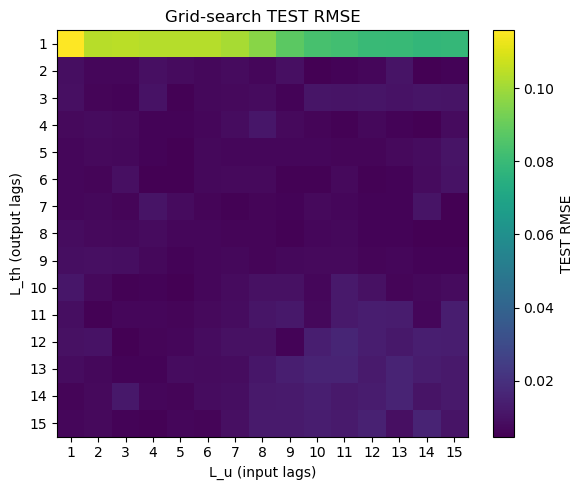

In [3]:
def build_features(u, th, L_th, L_u, max_lag, N_eff):
    """
    Build the features for the model based on the lags of u and th.
    """
    X = np.zeros((N_eff, L_th + L_u))
    Y = np.zeros(N_eff)
    # Loop over the length of the data
    for i in range(N_eff):
        k = max_lag + i
        y_lags = [th[k - j, 0] for j in range(L_th, 0, -1)]
        u_lags = [u[k - j, 0] for j in range(L_u, 0, -1)]
        X[i, :] = u_lags + y_lags
        Y[i]    = th[k, 0]
    return X, Y

def build_upast_thpast_thnow(u, th, L_u, L_th):
    """
    Build the past values of u and th for the model."""
    N = u.shape[0]
    max_lag = max(L_u, L_th)
    upast_val = np.hstack([u[max_lag - i : N - i, :] for i in range(L_u, 0, -1)])
    thpast_val = np.hstack([th[max_lag - i : N - i, :] for i in range(L_th, 0, -1)])
    thnow_val  = th[max_lag:, :]
    return upast_val, thpast_val, thnow_val

def build_model(X_train, Y_train, X_val, Y_val):
    """
    Build and compile the LSTM model.
    """
    # scale inputs
    scaler_x = StandardScaler()
    X_train_s = scaler_x.fit_transform(X_train)
    X_val_s   = scaler_x.transform(X_val)

    # scale targets
    scaler_y = StandardScaler()
    Y_train_s = scaler_y.fit_transform(Y_train.reshape(-1,1))
    Y_val_s   = scaler_y.transform(Y_val.reshape(-1,1))

    # Timesteps are the number of features in the input
    timesteps = X_train_s.shape[1]  

    # Build the LSTM model
    model = Sequential([
        Reshape((timesteps, 1), input_shape=(timesteps,)),
        LSTM(64, return_sequences=False),
        Dense(1, activation='linear')
    ])

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss='mse',
        metrics=[RootMeanSquaredError(name="rmse")]
    )

    model.summary()

    return X_train_s, Y_train_s, X_val_s, Y_val_s, model, scaler_x, scaler_y

# Grid search parameter space
L_th_list = list(range(1, 16))
L_u_list  = list(range(1, 16))

def run_grid_points(L_th, L_u):
    """ 
    Run grid search for the different combinations of L_th and L_u
    """
    max_lag = max(L_th, L_u)

    # train features
    N_eff_train = len(u_train) - max_lag
    X_train, Y_train = build_features(u_train, th_train, L_th, L_u, max_lag, N_eff_train)

    # val features
    N_eff_val = len(u_val) - max_lag
    X_val, Y_val   = build_features(u_val,   th_val,   L_th, L_u, max_lag, N_eff_val)

    # build & scale & compile
    X_train_s, Y_train_s, X_val_s, Y_val_s, model, scaler_x, scaler_y = build_model(X_train, Y_train, X_val, Y_val)

    # callbacks on val_loss (MSE)
    es  = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)
    rlp = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=20, min_lr=1e-5, verbose=1)

    # train (no shuffle for time series)
    history = model.fit(
        X_train_s, Y_train_s,
        validation_data=(X_val_s, Y_val_s),
        epochs=30,
        batch_size=256,
        shuffle=False,
        callbacks=[es, rlp],
        verbose=1
    )

    # build test features and predict
    upast_val, thpast_val, thnow_val = build_upast_thpast_thnow(u_test, th_test, L_u, L_th)
    X_test = np.hstack([upast_val, thpast_val])
    X_test_s = scaler_x.transform(X_test)
    Y_pred_s = model.predict(X_test_s, batch_size=64)
    Y_pred   = scaler_y.inverse_transform(Y_pred_s).flatten()

    # Calculate the RMSE
    rmse = sqrt(mean_squared_error(thnow_val.flatten(), Y_pred))
    print(f"L_th={L_th}, L_u={L_u}, TEST RMSE = {rmse:.4f}")
    return rmse

# Speed up the grid search using parallel processing
results_flat = Parallel(n_jobs=-1, verbose=10)(
    delayed(run_grid_points)(L_th, L_u)
    for L_th in L_th_list
    for L_u in L_u_list
)
results = np.array(results_flat).reshape(len(L_th_list), len(L_u_list))

# Save the sesults 
np.save("grid_rmse.npy", results)

# Plot the results
plt.figure(figsize=(6,5))
plt.imshow(results, aspect='auto', cmap='viridis')
plt.colorbar(label='TEST RMSE')
plt.xticks(range(len(L_u_list)), L_u_list)
plt.yticks(range(len(L_th_list)), L_th_list)
plt.xlabel('L_u (input lags)')
plt.ylabel('L_th (output lags)')
plt.title('Grid-search TEST RMSE')
plt.tight_layout()
plt.show()

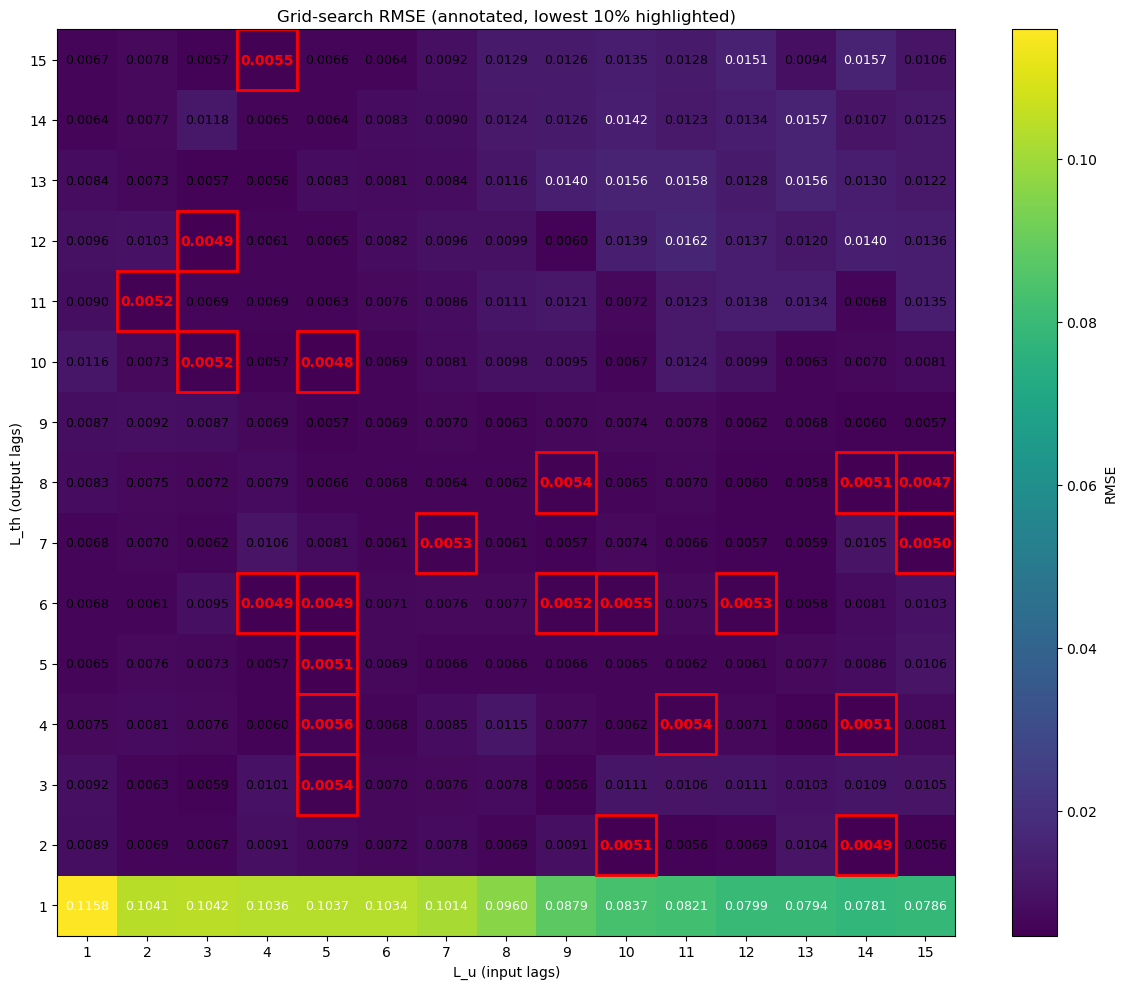

In [4]:
# Load the results
results = np.load("grid_rmse.npy") 
L_th_list = list(range(1, 16))
L_u_list = list(range(1, 16))

# Take the lowest xx percent of the results and highlight it 
flat = results.flatten()
n_top = int(0.1 * flat.size)
lowest_indices = np.argpartition(flat, n_top)[:n_top]
highlight_mask = np.zeros_like(flat, dtype=bool)
highlight_mask[lowest_indices] = True
highlight_mask = highlight_mask.reshape(results.shape)

# Plot the results with highlights
plt.figure(figsize=(12,10))
im = plt.imshow(results, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(im, label='RMSE')
plt.xticks(range(len(L_u_list)), L_u_list)
plt.yticks(range(len(L_th_list)), L_th_list)
plt.xlabel('L_u (input lags)')
plt.ylabel('L_th (output lags)')
plt.title('Grid-search RMSE (annotated, lowest 10% highlighted)')

# Annotate the grid with results and highlight the lowest xx percent
for i in range(results.shape[0]):
    for j in range(results.shape[1]):
        txt = f"{results[i,j]:.4f}"
        if highlight_mask[i, j]:
            plt.text(j, i, txt, ha='center', va='center', color='red', fontsize=10, fontweight='bold')
            plt.gca().add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='red', linewidth=2))
        else:
            color = 'white' if results[i,j] > results.mean() else 'black'
            plt.text(j, i, txt, ha='center', va='center', color=color, fontsize=9)

plt.tight_layout()
plt.show()



In [5]:
# Look for the best hyperparameters
best_idx = np.unravel_index(np.argmin(results), results.shape)
L_th_best = L_th_list[best_idx[0]]
L_u_best = L_u_list[best_idx[1]]
print(f"Best hyperparameters: L_th = {L_th_best}, L_u = {L_u_best}")
# print the best rmse
best_rmse = results[best_idx]
print(f"Best RMSE = {best_rmse:.4f} for L_th = {L_th_best}, L_u = {L_u_best}")

Best hyperparameters: L_th = 8, L_u = 15
Best RMSE = 0.0047 for L_th = 8, L_u = 15


## Retrain with best hyperparameters

In [6]:
# Build features for the test set using u_test, th_test
upast_val, thpast_val, thnow_val = build_upast_thpast_thnow(u_test, th_test, L_u_best, L_th_best)
thnow_pred = np.zeros_like(thnow_val)
# Save as .npz
np.savez(f"subset_{len(u_test)}_prediction.npz", upast=upast_val, thpast=thpast_val, thnow=thnow_pred)
np.savez(f"subset_{len(u_test)}_answers_prediction.npz", upast=upast_val, thpast=thpast_val, thnow=thnow_val)

# Calculate the maximum lag for the final model
max_lag = max(L_th_best, L_u_best)

# Combine train + val for full training
u_final = np.vstack([u_train, u_val])
th_final = np.vstack([th_train, th_val])

# Build final training features
N_eff_final = len(u_final) - max_lag
X_final, Y_final = build_features(u_final, th_final, L_th_best, L_u_best, max_lag, N_eff_final)

# Build test features
N_eff_test = len(u_test) - max_lag
X_test, Y_test = build_features(u_test, th_test, L_th_best, L_u_best, max_lag, N_eff_test)

# Build and train final model
X_final_s, Y_final_s, X_test_s, Y_test_s, model_final, scaler_x_final, scaler_y_final = build_model(X_final, Y_final, X_test, Y_test)

es  = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)
rlp = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=20, min_lr=1e-5, verbose=1)

history_final = model_final.fit(
    X_final_s, Y_final_s,
    validation_data=(X_test_s, Y_test_s),  
    epochs=500,
    batch_size=256,
    shuffle=False,
    callbacks=[es, rlp],
    verbose=1
)

# Predict on test
Y_pred_s = model_final.predict(X_test_s, batch_size=64)
Y_pred = scaler_y_final.inverse_transform(Y_pred_s).flatten()
rmse_test = sqrt(mean_squared_error(Y_test.flatten(), Y_pred))

print(f"Final RMSE = {rmse_test:.4f} ")


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 23, 1)             0         
                                                                 
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 16961 (66.25 KB)
Trainable params: 16961 (66.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/500
123/123 [==============================] - 5s 32ms/step - loss: 0.3605 - rmse: 0.6004 - val_loss: 0.0056 - val_rmse: 0.0748 - lr: 0.0010
Epoch 2/500
123/123 [==============================] - 4s 29ms/step - loss: 0.0026 - rmse: 0.0510 - val_loss: 0.0024 - val_rmse: 0.0492

## Make a file for submission-file-checker

In [7]:
# Load the prediction file for self-checking
pred_file = f"subset_{len(u_test)}_prediction.npz"
pred_data = np.load(pred_file)
upast_pred  = pred_data['upast']
thpast_pred = pred_data['thpast']

X_pred = np.hstack([upast_pred, thpast_pred])
X_pred_s = scaler_x_final.transform(X_pred)
Y_pred_s = model_final.predict(X_pred_s, batch_size=64)
Y_pred = scaler_y_final.inverse_transform(Y_pred_s).flatten()

# Show first restults
print("First 10 predictions:", Y_pred[:10])

# Save the predictions for self-checking using 'python submission-file-checker.py subset_<set value>_prediction_filled.npz subset_<set value>_answers_prediction.npz 
out_file = f"subset_{len(u_test)}_prediction_filled.npz"
np.savez(
    out_file,
    upast = upast_pred,
    thpast = thpast_pred,
    thnow = Y_pred
)


55/55 [==============================] - 0s 2ms/step
First 10 predictions: [ 0.90331036  0.84302604  0.7068561   0.49774215  0.2295229  -0.06171427
 -0.35383222 -0.6199756  -0.8397763  -0.98972046]


## Build file for prediction

In [8]:
# Load the hidden test prediction file for final submission
pred_file = "hidden-test-prediction-submission-file.npz"
pred_data = np.load(pred_file)
upast_pred = pred_data['upast']  
thpast_pred = pred_data['thpast'] 

# Build the features for prediction
X_pred = np.hstack([upast_pred, thpast_pred])
L_u = L_u_best
L_th = L_th_best
X_pred = np.hstack([
    upast_pred[:, :L_u],
    thpast_pred[:, :L_th]
])

# Make predictions with the final model
X_pred_s = scaler_x_final.transform(X_pred)
Y_pred_s = model_final.predict(X_pred_s, batch_size=64)
Y_pred = scaler_y_final.inverse_transform(Y_pred_s).flatten()

# Show first results
print(f"First 10 predictions: {Y_pred[:10]}")

#Save the predictions in a file for submission
out_file = "hidden-test-prediction-submission-file-filled.npz"
np.savez(
    out_file,
    upast  = upast_pred,
    thpast = thpast_pred,
    thnow  = Y_pred
)


11/11 [==============================] - 0s 2ms/step
First 10 predictions: [-0.22717385  0.35635042 -0.03689271 -0.23385645 -0.08130527  0.41454
  1.3113282  -0.2977066  -0.5848795   0.08453099]


## Build file for simulation

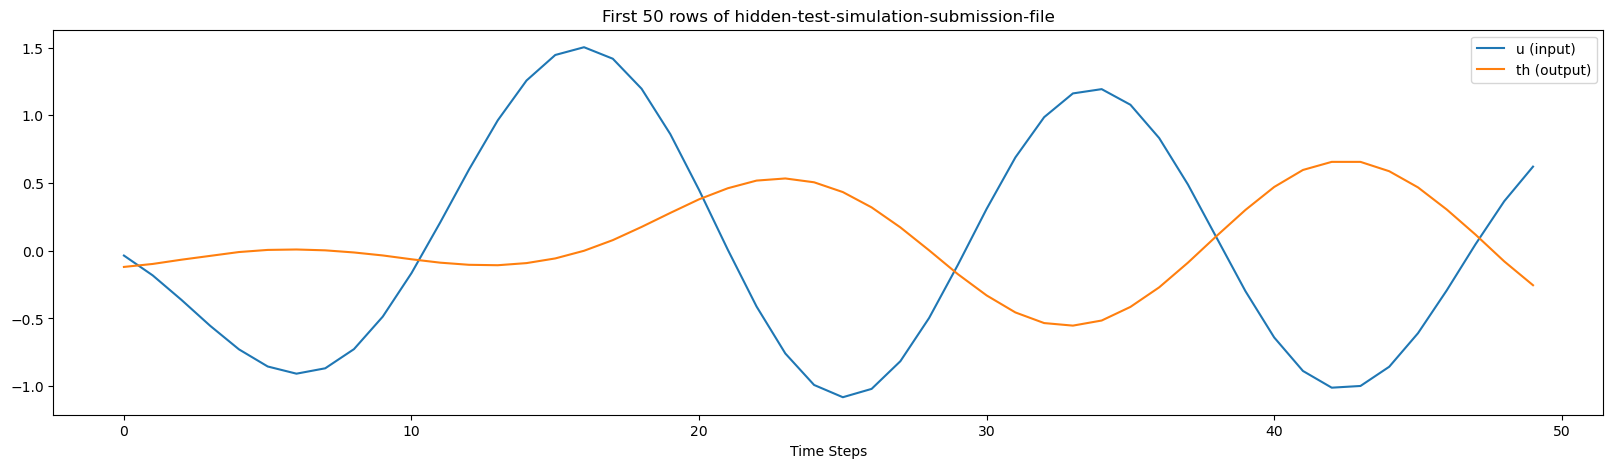

In [9]:
# plot only the first 50 rows of the hidden-test-simulation-submission-file
sim_file = "hidden-test-simulation-submission-file.npz"
sim_data = np.load(sim_file)
sim_u = sim_data['u'].reshape(-1, 1)
sim_th = sim_data['th'].reshape(-1, 1)
plt.figure(figsize=(20, 5))
plt.plot(sim_u[:50], label='u (input)')
plt.plot(sim_th[:50], label='th (output)')
plt.xlabel('Time Steps')
plt.legend()
plt.title('First 50 rows of hidden-test-simulation-submission-file')
plt.show()

In [10]:
# Load the hidden test simulation file for submission
sim = np.load("hidden-test-simulation-submission-file.npz")
u = sim["u"].reshape(-1, 1)
th_true = sim["th"].reshape(-1, 1)

th_sim = th_true.copy()
N = len(u)

# Start the simulation from 50th row 
start = max(50, max(L_u_best, L_th_best))
for k in range(start, N):
    # Build the lags for u and th based on the best hyperparameters
    u_lags = [u[k - j, 0] for j in range(L_u_best,  0, -1)]
    y_lags = [th_sim[k - j, 0] for j in range(L_th_best, 0, -1)]
    x = np.array(u_lags + y_lags).reshape(1, -1)
    
    # Scale, predict and inverse the scaling
    x_s = scaler_x_final.transform(x)
    y_s = model_final.predict(x_s, batch_size=1)
    y_pred = scaler_y_final.inverse_transform(y_s)[0, 0]
    
    # Save the preditcions
    th_sim[k, 0] = y_pred

# Save it in a new file for submission
np.savez("hidden-test-simulation-filled.npz", u=u, th=th_sim)


1/1 [==============================] - 0s 12ms/step


<Figure size 640x480 with 0 Axes>

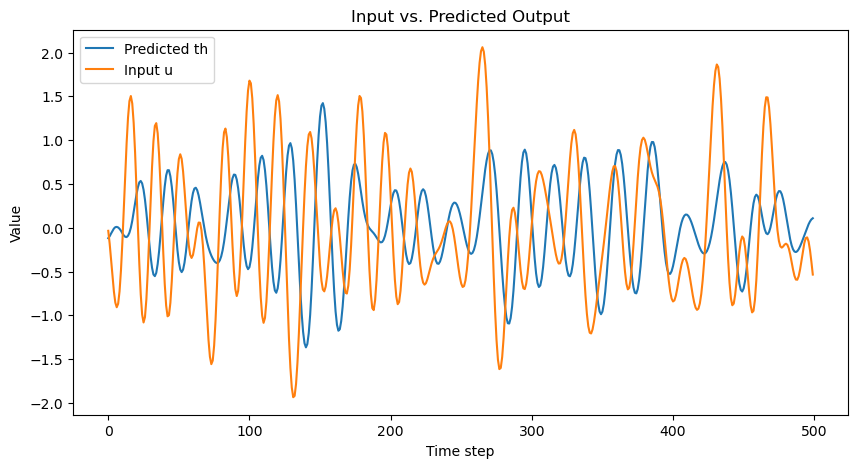

In [11]:
# Plot the first xx rows defined by parameter
parameter =500

# Plot the first xx rows of the simulated th and u 
plt.figure()
plt.figure(figsize=(10, 5))
plt.plot(range(parameter), th_sim[:parameter], label='Predicted th')
plt.plot(range(parameter), u[:parameter], label='Input u')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.title('Input vs. Predicted Output')
plt.legend()
plt.show()



## Validate simulation with validation data

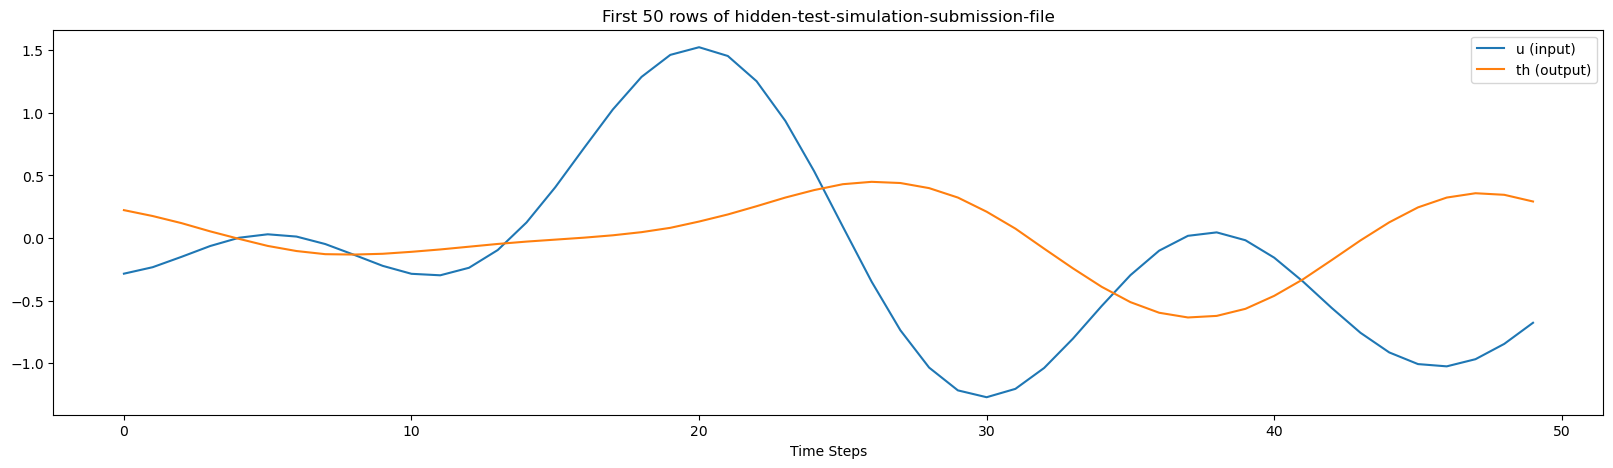

In [12]:
# Use the u_va and th_val for validating 
plt.figure(figsize=(20, 5))
plt.plot(u_val[:50], label='u (input)')
plt.plot(th_val[:50], label='th (output)')
plt.xlabel('Time Steps')
plt.legend()
plt.title('First 50 rows of hidden-test-simulation-submission-file')
plt.show()


In [13]:
u = u_val
# Take the first 50 values from th_val, rest zeros
th_true = np.zeros_like(th_val)
print(th_true)

# Replace the first 50 values of th_true with the first 50 values of th_val
th_true[:50] = th_val[:50]
print(th_true)

np.savez("simulation_ann_validation.npz", u=u, th=th_val)

th_sim = th_true.copy()
N = len(u_val)

# Start the simulation from 50th row
start = max(50, max(L_u_best, L_th_best))
for k in range(start, N):
    u_lags = [u[k - j, 0] for j in range(L_u_best,  0, -1)]
    y_lags = [th_sim[k - j, 0] for j in range(L_th_best, 0, -1)]
    x = np.array(u_lags + y_lags).reshape(1, -1)
    
    # Scale, predict and inverse the scaling
    x_s = scaler_x_final.transform(x)
    y_s = model_final.predict(x_s, batch_size=1)
    y_pred = scaler_y_final.inverse_transform(y_s)[0, 0]
    
    # Save the prediction
    th_sim[k, 0] = y_pred

np.savez("simulation_ann_validation_filled.npz", u=u, th=th_sim)
    

[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
[[0.22305308]
 [0.17592919]
 [0.11938052]
 ...
 [0.        ]
 [0.        ]
 [0.        ]]
1/1 [==============================] - 0s 11ms/step


<Figure size 640x480 with 0 Axes>

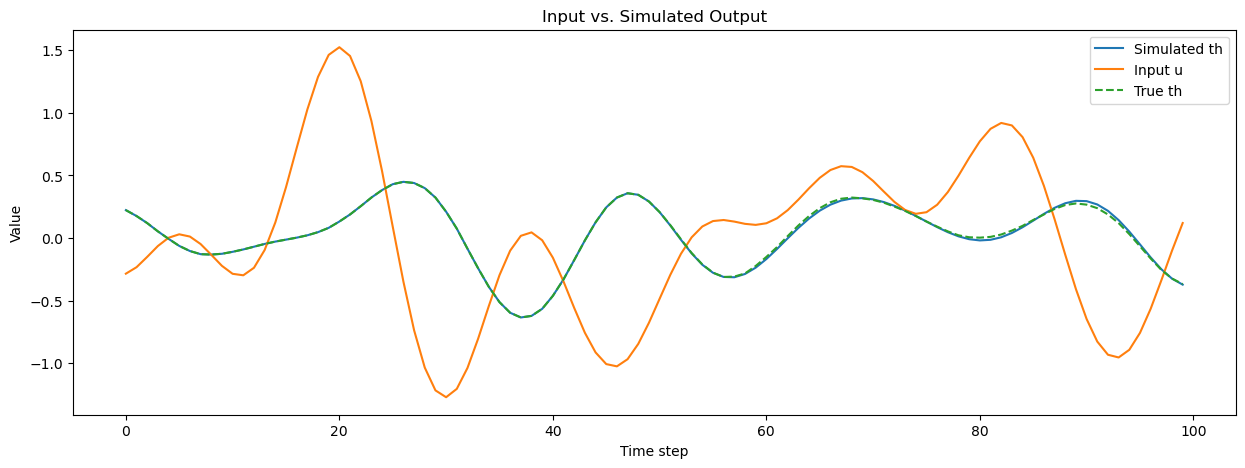

In [14]:
start = 0
stop = 100

#start = 3300
#stop = 3500

plt.figure()
plt.figure(figsize=(15, 5))
plt.plot(range(start, stop), th_sim[start:stop], label='Simulated th')
plt.plot(range(start, stop), u[start:stop], label='Input u')
plt.plot(range(start, stop), th_val[start:stop], label='True th', linestyle='--')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.title('Input vs. Simulated Output')
plt.legend()
plt.show()

In [15]:
# Calculate the RMSE between th_sim and th_val
rmse_val = sqrt(mean_squared_error(th_val, th_sim))
print(f"Validation RMSE = {rmse_val:.4f}")

Validation RMSE = 0.0292
